# Intro

In this project we will train 3 models:

1. Autoencoder model on FashionMNIST dataset, to get insight on data
2. Naive Classification Model on 10 epochs to see how it performs
3. Informed Classification Model to which we're going to transfer encoding layers' weights from pretrained Autoencoder.

We expect to see that Informed Classification Model will perform better than Naive Classification Model.

# Conclussion

We've received counter-intuitive outcome. The reason behind fact that Naive Model after training on same amount of epochs as Informed Model performed better, is that Naive Model starts from scratch. Intuitively we could expect that transferred weights from pretrained Autoencoder will boost our Informed Model, while it's actually the opposite. Autoencoder learns completely other features of input that serves to recreating the input as accurate as it's possible, while Classification Model learns features that help to classify the model.

Eventually having Autoencoder "memory" in Classification Model before training is not a boost but disadvantage. Our Informed Model, needs to "defeat memory" of Autoencoder first to proceed to classification learning. That's why performance of Informed Model is slightly worse than performance of Naive Model throughout same amount of epochs.

# Libs

In [1]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
from torchvision import transforms as T
from torch.utils.data import DataLoader, Subset

import copy

import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

/tmp/ipython-input-2439579802.py:15: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

# Data

In [3]:
# transform
transform = T.Compose([
    T.ToTensor(),
    T.RandomHorizontalFlip(.5),
    T.Normalize(.5,.5),
])

train_dataset = torchvision.datasets.FashionMNIST(root = './data', train = True, download = True, transform = transform)
val_test_dataset = torchvision.datasets.FashionMNIST(root = './data', train = False, download = True, transform = transform)

In [4]:
train_dataset, val_test_dataset

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: ./data
     Split: Train
     StandardTransform
 Transform: Compose(
                ToTensor()
                RandomHorizontalFlip(p=0.5)
                Normalize(mean=0.5, std=0.5)
            ),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: ./data
     Split: Test
     StandardTransform
 Transform: Compose(
                ToTensor()
                RandomHorizontalFlip(p=0.5)
                Normalize(mean=0.5, std=0.5)
            ))

In [5]:
idxs = np.random.permutation(10000)
val_dataset = Subset(val_test_dataset, idxs[:6000])
test_dataset = Subset(val_test_dataset, idxs[6000:])

In [6]:
batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, drop_last = True)
test_dataloader = DataLoader(test_dataset, batch_size = len(test_dataset))
val_dataloader = DataLoader(val_dataset, batch_size = len(val_dataset))

In [7]:
# inspect a few random images
X, y = next(iter(test_dataloader))

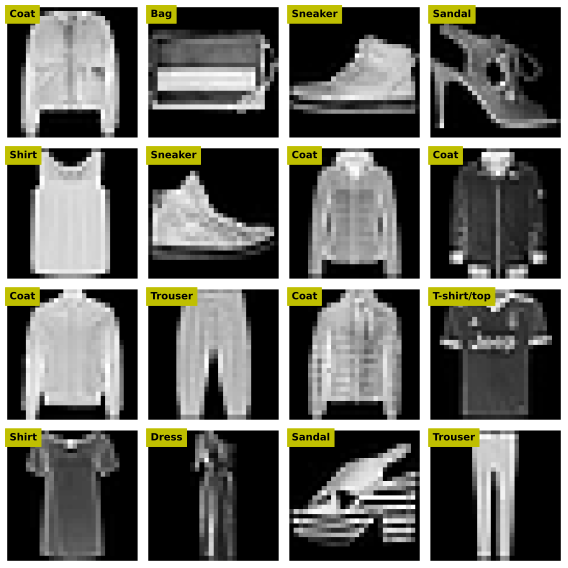

In [8]:
fig, axs = plt.subplots(4,4,figsize = (8,8))

for (i, ax) in enumerate(axs.flatten()):

  pic = X.data[i].numpy().transpose((1,2,0))

  # labels
  label = train_dataset.classes[y[i]]

  # show
  ax.imshow(pic, cmap = 'grey')
  ax.text(0,0,label,ha='left',va='top',fontweight='bold', color='k',backgroundcolor='y')
  ax.axis('off')

plt.tight_layout()
plt.show()

# Autoencoder Model

ConvTranspose2d:

$$ out = (In-1) \cdot S - 2P + K + \text{output_padding} $$

In [9]:
def CreateAEModel(print_toggle = False):

  class CreateAENet(nn.Module):
    def __init__(self, print_toggle):
      super().__init__()

      # print toggle
      self.print = print_toggle

      ### -------- encoder layers --------- ###
      # first convolution layer
      self.enc_conv_1 = nn.Conv2d(1, 16, 3, padding = 1, stride = 2)
      # output size: (28 + 2*1-3) / 2 + 1 = 14

      # second convolution layer
      self.enc_conv_2 = nn.Conv2d(16, 32, 3, padding = 1, stride = 2)
      # output size: (14+2*1-3)/2 + 1 = 7

      ### --------- decoder layers --------- ###
      # first convolution layer
      self.dec_conv_1 = nn.ConvTranspose2d(32, 16, 4, padding = 1, stride = 2)
      # output size: (7 - 1) * 2 - 2*1 + 4 + 0 = 14

      # second convolution layer
      self.dec_conv_2 = nn.ConvTranspose2d(16, 1, 4, padding = 1, stride = 2)
      # output size: (14 - 1) * 2 - 2*1 + 4 + 0 = 28

    def forward(self, x):

      if self.print: print(f'Input: {list(x.shape)}')

      # first encoder layer
      x = F.leaky_relu(self.enc_conv_1(x))
      if self.print: print(f'First encoder layer: {list(x.shape)}')

      # second encoder layer
      x = F.leaky_relu(self.enc_conv_2(x))
      if self.print: print(f'Second encoder layer: {list(x.shape)}')

      # first decoder layer
      x = F.leaky_relu(self.dec_conv_1(x))
      if self.print: print(f'First decoder layer: {list(x.shape)}')

      # second decoder layer
      x = F.leaky_relu(self.dec_conv_2(x))
      if self.print: print(f'Second decoder layer: {list(x.shape)}')

      return x

  # create the model instance
  net = CreateAENet(print_toggle)

  # loss function
  loss_fn = nn.MSELoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(), lr = .001)

  return net, loss_fn, optimizer

In [10]:
# test the model with one batch
temp_net, loss_fn, optimizer = CreateAEModel(True)

X, y = next(iter(train_dataloader))
y_hat = temp_net(X)

# check sie of output
print('\nOutput size:')
print(y_hat.shape)

# now let's compute the loss
loss = loss_fn(y_hat, X)
print(' ')
print('Loss:')
print(loss)

Input: [32, 1, 28, 28]
First encoder layer: [32, 16, 14, 14]
Second encoder layer: [32, 32, 7, 7]
First decoder layer: [32, 16, 14, 14]
Second decoder layer: [32, 1, 28, 28]

Output size:
torch.Size([32, 1, 28, 28])
 
Loss:
tensor(0.6934, grad_fn=<MseLossBackward0>)


## Train

In [11]:
def ModelAETrain(verbose, print_inf, epochs):

    net, loss_fn, optimizer = CreateAEModel(print_inf)
    net.to(device)

    train_losses = torch.zeros(epochs)
    val_losses   = torch.zeros(epochs)

    for epoch in range(epochs):
        net.train()
        batch_loss = []

        # --- TRAIN ---
        for X, _ in train_dataloader:   # y ignored
            X = X.to(device)

            X_hat = net(X)
            loss = loss_fn(X_hat, X)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_loss.append(loss.item())

        train_losses[epoch] = torch.tensor(batch_loss).mean()

        # --- VALIDATION ---
        net.eval()
        with torch.no_grad():
            X, _ = next(iter(val_dataloader))
            X = X.to(device)
            X_hat = net(X)
            val_losses[epoch] = loss_fn(X_hat, X).item()

        if verbose:
            print(
                f"Epoch {epoch} | "
                f"Train loss: {train_losses[epoch]:.4f} | "
                f"Val loss: {val_losses[epoch]:.4f}"
            )

    return train_losses, val_losses, net

In [12]:
ae_train_losses, ae_val_losses, ae_net = ModelAETrain(verbose = True, print_inf = False, epochs = 10)

Epoch 0 | Train loss: 0.0974 | Val loss: 0.0438
Epoch 1 | Train loss: 0.0345 | Val loss: 0.0275
Epoch 2 | Train loss: 0.0226 | Val loss: 0.0204
Epoch 3 | Train loss: 0.0159 | Val loss: 0.0143
Epoch 4 | Train loss: 0.0128 | Val loss: 0.0118
Epoch 5 | Train loss: 0.0111 | Val loss: 0.0105
Epoch 6 | Train loss: 0.0096 | Val loss: 0.0086
Epoch 7 | Train loss: 0.0080 | Val loss: 0.0074
Epoch 8 | Train loss: 0.0071 | Val loss: 0.0071
Epoch 9 | Train loss: 0.0063 | Val loss: 0.0061


## Plots

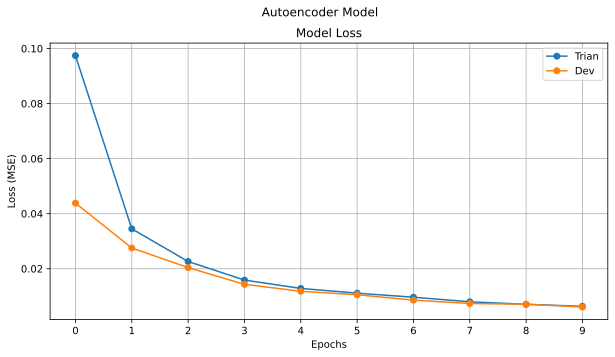

In [13]:
plt.figure(figsize = (10,5))
plt.plot(ae_train_losses, '-o', label = 'Trian')
plt.plot(ae_val_losses, '-o', label = 'Dev')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Model Loss')
plt.xticks(range(len(ae_train_losses)))
plt.legend()
plt.grid()
plt.suptitle('Autoencoder Model')
plt.show()

Display how Autoencoder recreates our input images.

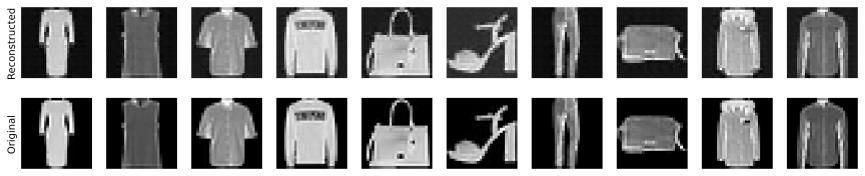

In [14]:
## show some random examples

# get some data
X, y = next(iter(val_dataloader))

# forward pass and loss
ae_net.cpu()
ae_net.eval()
y_hat = ae_net(X)

fig, axs = plt.subplots(2, 10, figsize = (15, 3))

for i in range(10):
  pic = y_hat[i,0,:,:].detach()
  pic = pic/2 + .5 # undo normalization
  axs[0,i].imshow(pic, cmap = 'gray')
  axs[0,i].axis('off')

  pic = X[i,0,:,:].detach()
  pic = pic/2 + .5 # undo normalization
  axs[1,i].imshow(pic, cmap = 'gray')
  axs[1,i].axis('off')

  if i == 0:
    axs[0,0].text(-6,14,'Reconstructed', rotation = 90, va = 'center')
    axs[1,0].text(-6,14, 'Original', rotation = 90, va = 'center')

plt.show()

# Naive Classification Model

In [15]:
def CreateNaiveClassModel(print_toggle = False):

  class CreateNaiveClassNet(nn.Module):
    def __init__(self, print_toggle):
      super().__init__()

      self.print = print_toggle

      ### --------- encoder layers --------- ###
      # first convolution layer
      self.enc_conv_1 = nn.Conv2d(1,16,3,padding=1,stride=2)
      # output size: (28 + 2*1 -3) / 2 + 1 = 14

      # second convolution layer
      self.enc_conv_2 = nn.Conv2d(16,32,3,padding=1,stride=2)
      # output size: (14+2*1-3)/2 + 1 = 7

      ### --------- linear layers ---------- ###
      self.fc1 = nn.Linear(7*7*32, 50)
      self.fc2 = nn.Linear(50,10)

    def forward(self, x):

      if self.print: print(f'Input: {list(x.shape)}')

      # first encoder layer
      x = F.leaky_relu(self.enc_conv_1(x))
      if self.print: print(f'First encoder layer: {list(x.shape)}')

      # second encoder layer
      x = F.leaky_relu(self.enc_conv_2(x))
      if self.print: print(f'Second encoder layer: {list(x.shape)}')

      # reshape to linear
      n_units = x.shape.numel()/x.shape[0]
      x = x.view(-1,int(n_units))
      if self.print: print(f'Post-convolution vectorized: {list(x.shape)}')

      # linear layers
      x = F.leaky_relu(self.fc1(x))
      if self.print: print(f'First linear layer: {list(x.shape)}')

      x = F.leaky_relu(self.fc2(x))
      if self.print: print(f'Second linear layer: {list(x.shape)}')

      return x

  # create the model isntance
  net = CreateNaiveClassNet(print_toggle)

  # loss function
  loss_fn = nn.CrossEntropyLoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(), lr = .001)

  return net, loss_fn, optimizer

In [16]:
# test the model with one batch
temp_net, loss_fn, optimizer = CreateNaiveClassModel(True)

X, y = next(iter(train_dataloader))
y_hat = temp_net(X)

# check sie of output
print('\nOutput size:')
print(y_hat.shape)

# now let's compute the loss
loss = loss_fn(y_hat, y)
print(' ')
print('Loss:')
print(loss)

Input: [32, 1, 28, 28]
First encoder layer: [32, 16, 14, 14]
Second encoder layer: [32, 32, 7, 7]
Post-convolution vectorized: [32, 1568]
First linear layer: [32, 50]
Second linear layer: [32, 10]

Output size:
torch.Size([32, 10])
 
Loss:
tensor(2.2990, grad_fn=<NllLossBackward0>)


## Train

In [18]:
naive_class_net, loss_fn, optimizer = CreateNaiveClassModel(print_toggle = False)

In [19]:
def ModelNaiveClassTrain(net, verbose, print_inf, epochs):

    net.to(device)

    train_losses = torch.zeros(epochs)
    val_losses   = torch.zeros(epochs)
    train_accs   = torch.zeros(epochs)
    val_accs     = torch.zeros(epochs)

    for epoch in range(epochs):
        net.train()
        batch_losses = []
        correct = 0
        total = 0

        # --- TRAIN ---
        for X, y in train_dataloader:
            X = X.to(device)
            y = y.to(device)

            logits = net(X)
            loss = loss_fn(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        train_losses[epoch] = torch.tensor(batch_losses).mean()
        train_accs[epoch] = correct / total

        # --- VALIDATION ---
        net.eval()
        correct = 0
        total = 0
        val_batch_losses = []

        with torch.no_grad():
            for X, y in val_dataloader:
                X = X.to(device)
                y = y.to(device)

                logits = net(X)
                loss = loss_fn(logits, y)

                val_batch_losses.append(loss.item())

                preds = torch.argmax(logits, dim=1)
                correct += (preds == y).sum().item()
                total += y.size(0)

        val_losses[epoch] = torch.tensor(val_batch_losses).mean()
        val_accs[epoch] = correct / total

        if verbose:
            print(
                f"Epoch {epoch} | "
                f"Train loss: {train_losses[epoch]:.4f} | "
                f"Train acc: {train_accs[epoch]:.4f} | "
                f"Val loss: {val_losses[epoch]:.4f} | "
                f"Val acc: {val_accs[epoch]:.4f}"
            )

    return train_losses, val_losses, train_accs, val_accs, net

In [20]:
naive_class_train_losses, naive_class_val_losses, naive_class_train_accs, naive_class_val_accs, naive_class_net = ModelNaiveClassTrain(net = naive_class_net,
                                                                                                                                       verbose = True,
                                                                                                                                       print_inf = False,
                                                                                                                                       epochs = 10)

Epoch 0 | Train loss: 0.5320 | Train acc: 0.8115 | Val loss: 0.3682 | Val acc: 0.8678
Epoch 1 | Train loss: 0.3284 | Train acc: 0.8818 | Val loss: 0.3251 | Val acc: 0.8837
Epoch 2 | Train loss: 0.2897 | Train acc: 0.8953 | Val loss: 0.3029 | Val acc: 0.8917
Epoch 3 | Train loss: 0.2640 | Train acc: 0.9034 | Val loss: 0.2990 | Val acc: 0.8932
Epoch 4 | Train loss: 0.2432 | Train acc: 0.9095 | Val loss: 0.2721 | Val acc: 0.9033
Epoch 5 | Train loss: 0.2258 | Train acc: 0.9164 | Val loss: 0.2634 | Val acc: 0.9077
Epoch 6 | Train loss: 0.2101 | Train acc: 0.9214 | Val loss: 0.2671 | Val acc: 0.9053
Epoch 7 | Train loss: 0.2020 | Train acc: 0.9252 | Val loss: 0.2801 | Val acc: 0.8963
Epoch 8 | Train loss: 0.1897 | Train acc: 0.9294 | Val loss: 0.2676 | Val acc: 0.9082
Epoch 9 | Train loss: 0.1796 | Train acc: 0.9335 | Val loss: 0.2647 | Val acc: 0.9123


## Pred

In [21]:
X, y = next(iter(test_dataloader))

X = X.to(device)
y = y.to(device)

with torch.no_grad():
  y_hat = naive_class_net(X)
  loss = loss_fn(y_hat, y)

naive_test_class_loss = loss.item()
naive_test_class_acc = torch.mean(
    (torch.argmax(y_hat, axis = 1) == y).float()
).item()

## Plots

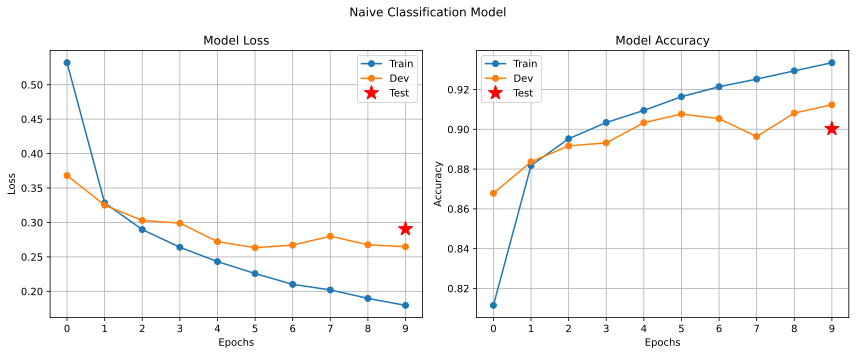

In [22]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --- LOSS ---
axs[0].plot(naive_class_train_losses, '-o', label='Train')
axs[0].plot(naive_class_val_losses, '-o', label='Dev')
axs[0].plot(len(naive_class_val_losses)-1, naive_test_class_loss, 'r*', markersize = 15, label = 'Test')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_title('Model Loss')
axs[0].set_xticks(range(len(naive_class_train_losses)))
axs[0].legend()
axs[0].grid()

# --- ACCURACY ---
axs[1].plot(naive_class_train_accs, '-o', label='Train')
axs[1].plot(naive_class_val_accs, '-o', label='Dev')
axs[1].plot(len(naive_class_val_accs)-1, naive_test_class_acc, 'r*', markersize = 15, label = 'Test')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_title('Model Accuracy')
axs[1].set_xticks(range(len(naive_class_train_accs)))
axs[1].legend()
axs[1].grid()

plt.suptitle('Naive Classification Model')
plt.tight_layout()
plt.show()

# Informed Classification Model

Let's create skeleton for informed_class_net

In [49]:
# test the model with one batch
informed_class_net, loss_fn, optimizer = CreateNaiveClassModel(print_toggle = False)

## Transfer Weights

In [50]:
ae_net

CreateAENet(
  (enc_conv_1): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (enc_conv_2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (dec_conv_1): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (dec_conv_2): ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
)

In [51]:
naive_class_net

CreateNaiveClassNet(
  (enc_conv_1): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (enc_conv_2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
)

We took care to have same encoding layers in autoencoder and naive_class_net, which now is pretrained on FashionMNIST data. Now, we can transfer weights from encoding layers of autoencoder to encoding layers of informed_class_net skeleton.

In [52]:
for source, target in zip(ae_net.named_parameters(), informed_class_net.named_parameters()):
  if 'enc' in source[0]:
    print('PRETRAIN: ' + target[0] + '  ->  AENET: ' + source[0])
    target[1].data = copy.deepcopy(source[1].data)

PRETRAIN: enc_conv_1.weight  ->  AENET: enc_conv_1.weight
PRETRAIN: enc_conv_1.bias  ->  AENET: enc_conv_1.bias
PRETRAIN: enc_conv_2.weight  ->  AENET: enc_conv_2.weight
PRETRAIN: enc_conv_2.bias  ->  AENET: enc_conv_2.bias


## Check Transfer

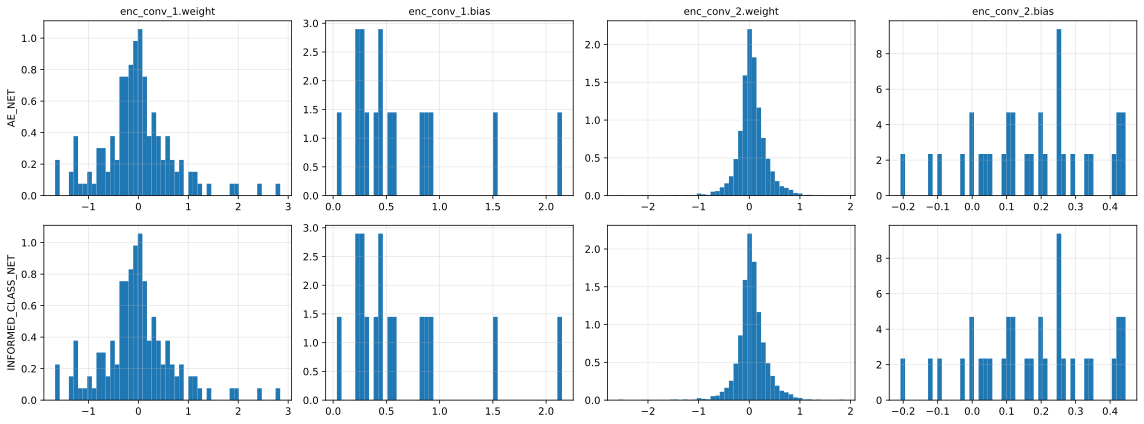

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def get_enc_weights(model):
    return {
        name: param.detach().cpu().flatten()
        for name, param in model.named_parameters()
        if "enc" in name
    }

ae_enc = get_enc_weights(ae_net)
inf_enc = get_enc_weights(informed_class_net)

# sanity: te same klucze
assert ae_enc.keys() == inf_enc.keys(), "ENC layers mismatch!"

layer_names = list(ae_enc.keys())
n_layers = len(layer_names)

fig, axs = plt.subplots(2, n_layers, figsize=(4*n_layers, 6), squeeze=False)

for i, layer in enumerate(layer_names):
    w_ae  = ae_enc[layer]
    w_inf = inf_enc[layer]

    # WSPÓLNY RANGE
    w_min = min(w_ae.min(), w_inf.min())
    w_max = max(w_ae.max(), w_inf.max())
    bins = np.linspace(w_min, w_max, 50)

    # AE
    axs[0, i].hist(w_ae, bins=bins, density=True)
    axs[0, i].set_title(layer, fontsize=10)
    axs[0, i].grid(alpha=0.3)

    # INFORMED
    axs[1, i].hist(w_inf, bins=bins, density=True)
    axs[1, i].grid(alpha=0.3)

axs[0, 0].set_ylabel("AE_NET")
axs[1, 0].set_ylabel("INFORMED_CLASS_NET")

plt.tight_layout()
plt.show()


We can see that weights and biases perfectly match so transfer was conducted properly.

## Raw Test

### Run Model on Test Set

Let's see how our informed_class_net, with weights transferred from a pretrained naive_class_net, performs without any fine-tuning or feature extraction.

In [54]:
X, y = next(iter(test_dataloader))

X = X.to(device)
y = y.to(device)

informed_class_net.to(device)

with torch.no_grad():
  y_hat = informed_class_net(X)
  loss = loss_fn(y_hat, y)

informed_test_class_loss = loss.item()
informed_test_class_acc = torch.mean(
    (torch.argmax(y_hat, axis = 1) == y).float()
).item()

In [55]:
informed_test_class_loss

2.8364505767822266

In [56]:
informed_test_class_acc

0.09350000321865082

### Plots

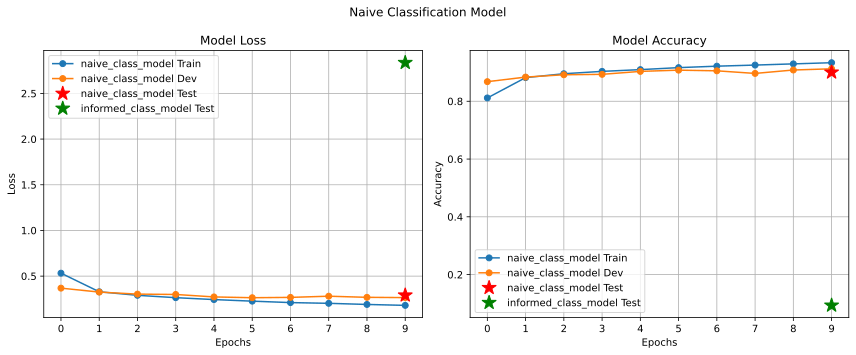

In [57]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --- LOSS ---
axs[0].plot(naive_class_train_losses, '-o', label='naive_class_model Train')
axs[0].plot(naive_class_val_losses, '-o', label='naive_class_model Dev')
axs[0].plot(len(naive_class_val_losses)-1, naive_test_class_loss, 'r*', markersize = 15, label = 'naive_class_model Test')
axs[0].plot(len(naive_class_val_losses)-1, informed_test_class_loss, 'g*', markersize = 15, label = 'informed_class_model Test')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_title('Model Loss')
axs[0].set_xticks(range(len(naive_class_train_losses)))
axs[0].legend()
axs[0].grid()

# --- ACCURACY ---
axs[1].plot(naive_class_train_accs, '-o', label='naive_class_model Train')
axs[1].plot(naive_class_val_accs, '-o', label='naive_class_model Dev')
axs[1].plot(len(naive_class_val_accs)-1, naive_test_class_acc, 'r*', markersize = 15, label = 'naive_class_model Test')
axs[1].plot(len(naive_class_val_accs)-1, informed_test_class_acc, 'g*', markersize = 15, label = 'informed_class_model Test')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_title('Model Accuracy')
axs[1].set_xticks(range(len(naive_class_train_accs)))
axs[1].legend()
axs[1].grid()

plt.suptitle('Naive Classification Model')
plt.tight_layout()
plt.show()

Without any training of informed_class_net we receive performance that is similar to completely raw model. That's because AE learns to reconstruct, to preserve low-level information and structure of input space. Classification, on the other hand requires invariant, discriminative features and rejecting information irrelevant for predicting classes.

## Fine Tune

### Train Model

In [58]:
informed_class_train_losses, informed_class_val_losses, informed_class_train_accs, informed_class_val_accs, informed_class_net = ModelNaiveClassTrain(net = informed_class_net,
                                                                                                                                                      verbose = True,
                                                                                                                                                      print_inf = False,
                                                                                                                                                      epochs = 10)

Epoch 0 | Train loss: 0.8551 | Train acc: 0.7045 | Val loss: 0.4282 | Val acc: 0.8508
Epoch 1 | Train loss: 0.3855 | Train acc: 0.8619 | Val loss: 0.4106 | Val acc: 0.8523
Epoch 2 | Train loss: 0.3342 | Train acc: 0.8794 | Val loss: 0.3539 | Val acc: 0.8782
Epoch 3 | Train loss: 0.3033 | Train acc: 0.8905 | Val loss: 0.3382 | Val acc: 0.8827
Epoch 4 | Train loss: 0.2776 | Train acc: 0.8985 | Val loss: 0.3172 | Val acc: 0.8848
Epoch 5 | Train loss: 0.2600 | Train acc: 0.9041 | Val loss: 0.3165 | Val acc: 0.8842
Epoch 6 | Train loss: 0.2436 | Train acc: 0.9106 | Val loss: 0.2950 | Val acc: 0.8933
Epoch 7 | Train loss: 0.2306 | Train acc: 0.9142 | Val loss: 0.2996 | Val acc: 0.8953
Epoch 8 | Train loss: 0.2158 | Train acc: 0.9199 | Val loss: 0.2971 | Val acc: 0.9020
Epoch 9 | Train loss: 0.2067 | Train acc: 0.9230 | Val loss: 0.2977 | Val acc: 0.8985


### Run Model on Test Set

In [59]:
X, y = next(iter(test_dataloader))

X = X.to(device)
y = y.to(device)

informed_class_net.to(device)

with torch.no_grad():
  y_hat = informed_class_net(X)
  loss = loss_fn(y_hat, y)

informed_test_class_loss = loss.item()
informed_test_class_acc = torch.mean(
    (torch.argmax(y_hat, axis = 1) == y).float()
).item()

### Plots

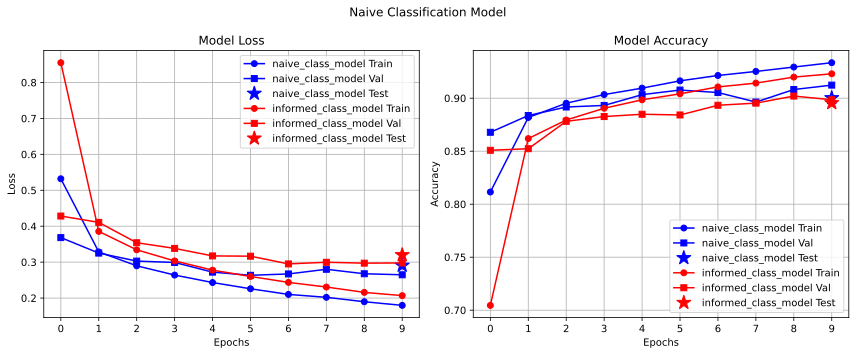

In [69]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --- LOSS ---
axs[0].plot(naive_class_train_losses, 'b-o', label='naive_class_model Train')
axs[0].plot(naive_class_val_losses, 'b-s', label='naive_class_model Val')
axs[0].plot(len(naive_class_val_losses)-1, naive_test_class_loss, 'b*', markersize = 15, label = 'naive_class_model Test')
axs[0].plot(informed_class_train_losses, 'r-o', label='informed_class_model Train')
axs[0].plot(informed_class_val_losses, 'r-s', label='informed_class_model Val')
axs[0].plot(len(informed_class_val_losses)-1, informed_test_class_loss, 'r*', markersize = 15, label = 'informed_class_model Test')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_title('Model Loss')
axs[0].set_xticks(range(len(naive_class_train_losses)))
axs[0].legend()
axs[0].grid()

# --- ACCURACY ---
axs[1].plot(naive_class_train_accs, 'b-o', label='naive_class_model Train')
axs[1].plot(naive_class_val_accs, 'b-s', label='naive_class_model Val')
axs[1].plot(len(naive_class_val_accs)-1, naive_test_class_acc, 'b*', markersize = 15, label = 'naive_class_model Test')
axs[1].plot(informed_class_train_accs, 'r-o', label='informed_class_model Train')
axs[1].plot(informed_class_val_accs, 'r-s', label='informed_class_model Val')
axs[1].plot(len(informed_class_val_accs)-1, informed_test_class_acc, 'r*', markersize = 15, label = 'informed_class_model Test')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_title('Model Accuracy')
axs[1].set_xticks(range(len(naive_class_train_accs)))
axs[1].legend()
axs[1].grid()

plt.suptitle('Naive Classification Model')
plt.tight_layout()
plt.show()

### Feature Map Activations Comparison

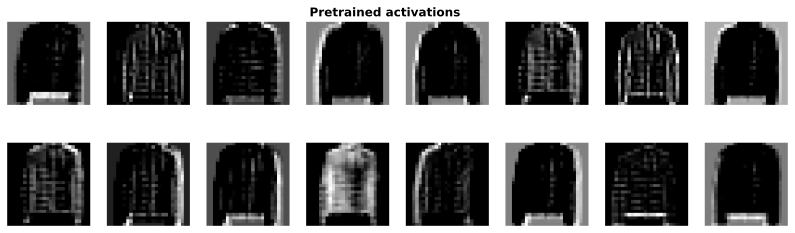

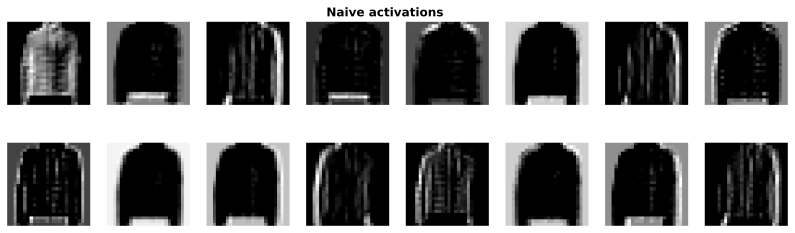

In [73]:
x = X[10,:,:,:].view(1,1,28,28)

# compute the activations of the first layer
layer_1_act_informed = F.relu(F.conv2d(x, informed_class_net.enc_conv_1.weight))
layer_1_act_naive = F.relu(F.conv2d(x, naive_class_net.enc_conv_1.weight))

## show the feature map actiations for the pretrained model
fig, axs = plt.subplots(2,8,figsize=(14,4))
for i, ax in enumerate(axs.flatten()):
  act = torch.squeeze(layer_1_act_informed[0,i,:,:]).detach().cpu()
  ax.imshow(act, cmap = 'gray')
  ax.axis('off')

plt.suptitle('Pretrained activations', y = .9, fontweight = 'bold')
plt.show()

## show the feature map actiations for the naive model
fig, axs = plt.subplots(2,8,figsize=(14,4))
for i, ax in enumerate(axs.flatten()):
  act = torch.squeeze(layer_1_act_naive[0,i,:,:]).detach().cpu()
  ax.imshow(act, cmap = 'gray')
  ax.axis('off')

plt.suptitle('Naive activations', y = .9, fontweight = 'bold')
plt.show()

There is no way to tell from feature maps what causes Informed Model to perform slightly worse than Naive Model.